<a href="https://colab.research.google.com/github/jsanchezv4/procesamiento/blob/main/S6_taller_aplicado_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 Taller de Aplicación: Análisis de Opiniones de Hoteles

**Sesión 6 — NLP para Analítica de Opiniones**

## 🎯 Objetivo
Aplicar las herramientas y técnicas aprendidas en las sesiones anteriores para realizar un análisis de sentimiento y exploración de texto sobre un conjunto de reseñas hoteleras en español.



## 1️⃣ Carga de datos

Para esta práctica se analizarán las reseñas de una cadena hotelera aplicando las técnicas de procesamiento de lenguaje natural que se han estudiado hasta el momento.

Para ello deben tener en cuenta que el [archivo](https://www.kaggle.com/datasets/beltrewilton/punta-cana-hotels-review-spanish?resource=download) `punta_cana.csv` contiene la siguiente información:

Esta colección contiene reseñas de hoteles en la zona de Punta Cana (República Dominicana) escritas en español. Cada entrada incluye típicamente el título de la reseña, el texto completo donde el huésped describe su experiencia, la puntuación en estrellas otorgada (1–5), el nombre del hotel, la ubicación de origen del autor de la reseña (ciudad y país) y la fecha (mes y año) de la visita o reseña.

Para la práctica vas a tener en cuenta que una reseña positiva es aquella con calificación mayor o igual a 3, en caso contrario será negativa.


In [3]:
from google.colab import drive
drive.mount('/content/drive') # aquí tu código para la carga de información...

Mounted at /content/drive


In [4]:
rutadearchivo = '/content/drive/MyDrive/procesamiento/punta_cana.csv'

In [5]:
import pandas as pd
datos=pd.read_csv(rutadearchivo)

In [6]:
datos.shape

(34561, 6)

In [7]:
datos.columns = datos.columns.str.upper()
display(datos.head())
print(datos.columns)

,HOTEL_NAME,LOCATION,WROTE,RATING,TITLE,REVIEW_TEXT
0,Secrets Cap Cana Resort & Spa,"Villaviciosa, Spain",December 2021,5,Vacaciones en El paraíso,El hotel impecable todo muy limpio las habitac...
1,Secrets Cap Cana Resort & Spa,"Villaviciosa, Spain",December 2021,5,HOTEL de la EXCELENCIA,"EXCELENTE, magnífico, excepcional, maravilloso..."
2,Secrets Cap Cana Resort & Spa,"Villaviciosa, Spain",December 2021,5,Sentirse como en CASA!!!!!,Tras conocer bastantes hoteles en distintos lu...
3,Secrets Cap Cana Resort & Spa,"Villaviciosa, Spain",December 2021,5,Muy buen nivel,Muy buen hotel. Cumple con todos los requisito...
4,Secrets Cap Cana Resort & Spa,"Villaviciosa, Spain",December 2021,5,10,Excelente todo ....sobre todo el personal. Es ...


Index(['HOTEL_NAME', 'LOCATION', 'WROTE', 'RATING', 'TITLE', 'REVIEW_TEXT'], dtype='object')


In [8]:
datos['label'] = datos['RATING'].apply(lambda x: 0 if x <= 2 else 1)
print("Class distribution in 'label' column:")
print(datos['label'].value_counts())
datos.columns = datos.columns.str.upper()
display(datos.head())
print(datos.columns)

Class distribution in 'label' column:
label
1    32327
0     2234
Name: count, dtype: int64


,HOTEL_NAME,LOCATION,WROTE,RATING,TITLE,REVIEW_TEXT,LABEL
0,Secrets Cap Cana Resort & Spa,"Villaviciosa, Spain",December 2021,5,Vacaciones en El paraíso,El hotel impecable todo muy limpio las habitac...,1
1,Secrets Cap Cana Resort & Spa,"Villaviciosa, Spain",December 2021,5,HOTEL de la EXCELENCIA,"EXCELENTE, magnífico, excepcional, maravilloso...",1
2,Secrets Cap Cana Resort & Spa,"Villaviciosa, Spain",December 2021,5,Sentirse como en CASA!!!!!,Tras conocer bastantes hoteles en distintos lu...,1
3,Secrets Cap Cana Resort & Spa,"Villaviciosa, Spain",December 2021,5,Muy buen nivel,Muy buen hotel. Cumple con todos los requisito...,1
4,Secrets Cap Cana Resort & Spa,"Villaviciosa, Spain",December 2021,5,10,Excelente todo ....sobre todo el personal. Es ...,1


Index(['HOTEL_NAME', 'LOCATION', 'WROTE', 'RATING', 'TITLE', 'REVIEW_TEXT',
       'LABEL'],
      dtype='object')


## 2️⃣ Preprocesamiento de texto

Unifica `title` y `review_text`, limpia el texto, elimina signos y stopwords, y crea una nueva columna `clean_text`.


In [9]:
!python -m spacy download es_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 21.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [10]:
import re
import spacy

In [11]:
nlp = spacy.load("es_core_news_md")

In [12]:
def clean_text(text: str) -> str:
    """
    Cleans and normalizes a Spanish text by removing punctuation, converting to lowercase,
    lemmatizing, and removing stopwords and punctuation using spaCy.

    Args:
        text (str): The input text to process.

    Returns:
        str: The cleaned and lemmatized text as a single string.
    """
    text = re.sub(r"[^\w\s]", "", str(text).lower(), flags=re.UNICODE)
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc if not token.is_stop and not token.is_punct])

In [11]:
# datos = datos.head(100)

In [13]:
datos["clean_text"] = datos["REVIEW_TEXT"].apply(clean_text)
datos["clean_text"].head()

,clean_text
0,hotel impecable limpio habitación amplio tipo ...
1,excelente magnífico excepcional maravilloso ad...
2,bastante hotel distinto lugar mundo secrets ca...
3,hotel cumplir requisito descansar atendido niv...
4,excelente personal diferenciar resort calidad ...


## 3️⃣ Exploración semántica y visual

Utiliza `spaCy` para analizar:
- Estructura gramatical (POS tagging)
- Entidades nombradas (NER)

Además, construye:
- Nube de palabras por clase
- Distribución de POS tags


In [14]:
datos["clean_text"][0]

'hotel impecable limpio habitación amplio tipo detalle medida cocid bufete tocar servir   piscina playa muchísimos camarero atento   especial fidelina bomba servir continuamente desinfectar mano coger bebidalo restaurante   barbacoa playa paella bufete poder malotodo personal súper amable divertidonuestro mayordomo gerlyn   diva compañero mr bluecherry etc divierta pases genial playa bonito'

In [15]:
datos["REVIEW_TEXT"][0]

'El hotel impecable todo muy limpio las habitaciones amplias y con todo tipo de detalles. Las medidas cocid estaban bien ya que en el bufete tú no tocas nada todo te lo sirven ellos . En la piscina y en la playa hay muchísimos camareros muy atentos , en especial Fidelina( es la bomba) que te sirven continuamente y te desinfectan las manos antes de coger la bebida.Los restaurantes , la barbacoa de la playa con la paella y el bufete de diez, no puedes decir que algo está malo.Todo el personal es súper amable y divertido.Nuestro mayordomo Gerlyn, un diez . Lo mejor LA DIVA, que junto a sus compañeros Mr Blue,cherry etc.. hacen que te diviertas y te lo pases genial .La playa muy bonita.'

In [16]:
def extract_nouns_adjs(text: str) -> list[tuple[str, str]]:
    """
    Extracts all nouns and adjectives from a given Spanish text using spaCy POS tagging.

    Args:
        text (str): The input text to analyze.

    Returns:
        list[tuple[str, str]]: A list of tuples where each tuple contains a word and its POS tag,
        limited to nouns ("NOUN") and adjectives ("ADJ").
    """
    doc = nlp(text)
    return [(token.text, token.pos_) for token in doc if token.pos_ in ["NOUN", "ADJ"]]

datos["nouns_adjs"] = datos["REVIEW_TEXT"].apply(extract_nouns_adjs)
datos[["REVIEW_TEXT", "nouns_adjs"]].head()

,REVIEW_TEXT,nouns_adjs
0,El hotel impecable todo muy limpio las habitac...,"[(hotel, NOUN), (impecable, ADJ), (limpio, ADJ..."
1,"EXCELENTE, magnífico, excepcional, maravilloso...","[(magnífico, ADJ), (excepcional, ADJ), (maravi..."
2,Tras conocer bastantes hoteles en distintos lu...,"[(hoteles, NOUN), (lugares, NOUN), (mundo, NOU..."
3,Muy buen hotel. Cumple con todos los requisito...,"[(buen, ADJ), (hotel, NOUN), (requisitos, NOUN..."
4,Excelente todo ....sobre todo el personal. Es ...,"[(Excelente, ADJ), (personal, NOUN), (resort, ..."


In [17]:
def noun_adj_pairs(text: str) -> list[tuple[str, str]]:
    """
    Extract (noun, adjective) pairs from a Spanish text using spaCy POS tagging.

    A pair is formed when a NOUN and an ADJ are found within a 2-token window of each other.

    Args:
        text (str): The input text to analyze.

    Returns:
        list[tuple[str, str]]: List of (noun, adjective) tuples found in the text.
    """
    doc = nlp(text)
    nouns = [token for token in doc if token.pos_ == "NOUN"]
    adjs = [token for token in doc if token.pos_ == "ADJ"]
    return [(noun.text, adj.text) for noun in nouns for adj in adjs if abs(noun.i - adj.i) <= 2]

In [18]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd
import spacy

In [19]:
nlp = spacy.load("es_core_news_md")

In [20]:
datos['clean_text']

,clean_text
0,hotel impecable limpio habitación amplio tipo ...
1,excelente magnífico excepcional maravilloso ad...
2,bastante hotel distinto lugar mundo secrets ca...
3,hotel cumplir requisito descansar atendido niv...
4,excelente personal diferenciar resort calidad ...
...,...
34556,definitivamente excelente opción servicio envi...
34557,fabuloso trato super comida excelente personal...
34558,hotel súper acogedor personal capacitado entre...
34559,calidad hotel primium estar febrero perfeccion...


In [21]:
datos['clean_text']
all_nouns = []
all_adjs = []
all_pairs = []

for text in datos["clean_text"]:
    doc = nlp(text)
    all_nouns.extend([token.text for token in doc if token.pos_ == "NOUN"])
    all_adjs.extend([token.text for token in doc if token.pos_ == "ADJ"])
    all_pairs.extend(noun_adj_pairs(text))

In [22]:
# Contar frecuencias
noun_freq = Counter(all_nouns)
adj_freq = Counter(all_adjs)
pair_freq = Counter(all_pairs)

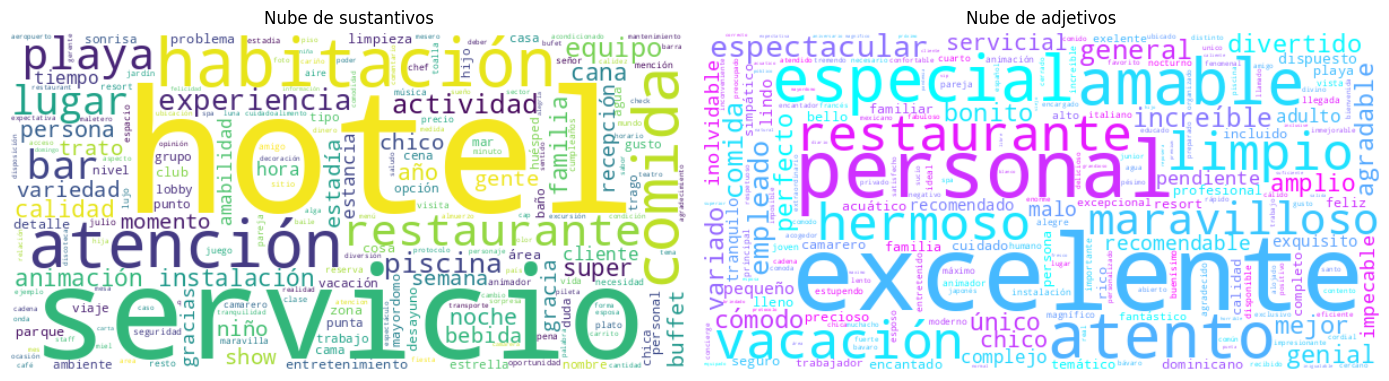

In [23]:
# Nubes de palabras
wc_nouns = WordCloud(width=600, height=300, background_color="white").generate_from_frequencies(noun_freq)
wc_adjs = WordCloud(width=600, height=300, background_color="white", colormap="cool").generate_from_frequencies(adj_freq)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(wc_nouns, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de sustantivos")

plt.subplot(1, 2, 2)
plt.imshow(wc_adjs, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de adjetivos")

plt.tight_layout()
plt.show()

## 4️⃣ Vectorización y entrenamiento de modelo

- Vectoriza los textos con TF-IDF
- Entrena un modelo de regresión logística para predecir el sentimiento
- Evalúa el desempeño del modelo (precision, recall, F1-score, matriz de confusión)


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [25]:
vectorizer = TfidfVectorizer(max_features=30)
X = vectorizer.fit_transform(datos["clean_text"])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df.head()

,actividad,amable,animación,atención,atento,bar,calidad,chico,comida,equipo,...,persona,personal,piscina,playa,restaurante,servicio,tener,vacación,volver,él
0,0.000000,0.283297,0.000000,0.0,0.28751,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.225107,0.258238,0.713950,0.233549,0.000000,0.0,0.0,0.000000,0.0
1,0.000000,0.322986,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.376907,...,0.361222,0.256644,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0
2,0.277921,0.000000,0.261432,0.0,0.00000,0.0,0.542190,0.0,0.0,0.000000,...,0.000000,0.189814,0.000000,0.000000,0.196932,0.498858,0.0,0.0,0.000000,0.0
3,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.477069,0.000000,0.504357,0.494961,0.000000,0.0,0.0,0.000000,0.0
4,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.543398,0.0,0.0,0.000000,...,0.000000,0.380473,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.461095,0.0


In [26]:
def extract_top_tfidf_words(tfidf_df: pd.DataFrame, top_n: int = 5) -> pd.DataFrame:
    """
    Extracts the top N words with the highest TF-IDF scores for each document in the input DataFrame.

    Args:
        tfidf_df (pd.DataFrame): A DataFrame where rows represent documents and columns are words,
                                 with TF-IDF scores as values.
        top_n (int, optional): Number of top words to extract per document. Default is 5.

    Returns:
        pd.DataFrame: A DataFrame with one row per document and two columns:
                      - 'Top_Words': list of the top N words
                      - 'Top_Scores': list of corresponding TF-IDF scores
    """
    top_words = []
    top_scores = []

    for _, row in tfidf_df.iterrows():
        top_items = row.sort_values(ascending=False).head(top_n)
        top_words.append(list(top_items.index))
        top_scores.append(list(top_items.values))

    return pd.DataFrame({
        "Top_Words": top_words,
        "Top_Scores": top_scores
    })

In [27]:
top_tfidf = extract_top_tfidf_words(tfidf_df.head())
top_tfidf.Top_Scores = top_tfidf.Top_Scores.apply(lambda x: [round(score, 2) for score in x])
top_tfidf

,Top_Words,Top_Scores
0,"[playa, especial, atento, amable, piscina]","[0.71, 0.29, 0.29, 0.28, 0.26]"
1,"[hotel, equipo, persona, familia, amable]","[0.53, 0.38, 0.36, 0.36, 0.32]"
2,"[calidad, servicio, actividad, experiencia, an...","[0.54, 0.5, 0.28, 0.26, 0.26]"
3,"[playa, restaurante, personal, excelente, hotel]","[0.5, 0.49, 0.48, 0.41, 0.33]"
4,"[calidad, especial, volver, personal, excelente]","[0.54, 0.49, 0.46, 0.38, 0.32]"


In [28]:
from collections import Counter

In [29]:
doc = nlp(datos["REVIEW_TEXT"].iloc[0])
for token in doc:
    print(f"{token.text:<15} {token.pos_:<10} {token.dep_:<15}")

El              DET        det            
hotel           NOUN       ROOT           
impecable       ADJ        amod           
todo            PRON       appos          
muy             ADV        advmod         
limpio          ADJ        amod           
las             DET        det            
habitaciones    NOUN       appos          
amplias         ADJ        amod           
y               CCONJ      cc             
con             ADP        case           
todo            DET        det            
tipo            NOUN       conj           
de              ADP        case           
detalles        NOUN       nmod           
.               PUNCT      punct          
Las             DET        det            
medidas         NOUN       nsubj          
cocid           PROPN      amod           
estaban         AUX        cop            
bien            ADV        ROOT           
ya              ADV        mark           
que             SCONJ      fixed          
en         

In [30]:
for ent in doc.ents:
    print(ent.text, ent.label_)

Las medidas cocid MISC
Fidelina LOC
Los restaurantes MISC
Todo el personal MISC
Nuestro PER
Gerlyn PER
Lo mejor LA DIVA MISC
Mr Blue MISC


In [31]:
all_pos = []
for doc in nlp.pipe(datos["REVIEW_TEXT"][:100], batch_size=20):
    all_pos.extend([token.pos_ for token in doc if not token.is_space])
all_pos

['DET',
 'NOUN',
 'ADJ',
 'PRON',
 'ADV',
 'ADJ',
 'DET',
 'NOUN',
 'ADJ',
 'CCONJ',
 'ADP',
 'DET',
 'NOUN',
 'ADP',
 'NOUN',
 'PUNCT',
 'DET',
 'NOUN',
 'PROPN',
 'AUX',
 'ADV',
 'ADV',
 'SCONJ',
 'ADP',
 'DET',
 'NOUN',
 'PRON',
 'ADV',
 'VERB',
 'PRON',
 'DET',
 'PRON',
 'PRON',
 'VERB',
 'PRON',
 'PUNCT',
 'ADP',
 'DET',
 'NOUN',
 'CCONJ',
 'ADP',
 'DET',
 'NOUN',
 'AUX',
 'DET',
 'NOUN',
 'ADV',
 'ADJ',
 'PUNCT',
 'ADP',
 'ADJ',
 'PROPN',
 'PUNCT',
 'AUX',
 'DET',
 'NOUN',
 'PUNCT',
 'PRON',
 'PRON',
 'VERB',
 'ADV',
 'CCONJ',
 'PRON',
 'VERB',
 'DET',
 'NOUN',
 'ADV',
 'ADP',
 'VERB',
 'DET',
 'NOUN',
 'PUNCT',
 'DET',
 'NOUN',
 'PUNCT',
 'DET',
 'NOUN',
 'ADP',
 'DET',
 'NOUN',
 'ADP',
 'DET',
 'NOUN',
 'CCONJ',
 'DET',
 'NOUN',
 'ADP',
 'NUM',
 'PUNCT',
 'ADV',
 'AUX',
 'VERB',
 'SCONJ',
 'PRON',
 'AUX',
 'ADJ',
 'PUNCT',
 'DET',
 'DET',
 'NOUN',
 'AUX',
 'ADV',
 'ADJ',
 'CCONJ',
 'ADJ',
 'PUNCT',
 'DET',
 'NOUN',
 'PROPN',
 'PUNCT',
 'DET',
 'NUM',
 'PUNCT',
 'PRON',
 'ADJ',


In [32]:
pos_counts = Counter(all_pos)
pos_counts

Counter({'DET': 1411,
         'NOUN': 1885,
         'ADJ': 877,
         'PRON': 551,
         'ADV': 451,
         'CCONJ': 445,
         'ADP': 1284,
         'PUNCT': 1229,
         'PROPN': 670,
         'AUX': 395,
         'SCONJ': 179,
         'VERB': 751,
         'NUM': 56,
         'SYM': 5,
         'PART': 3,
         'INTJ': 2})

In [33]:
pos_counts.items()

dict_items([('DET', 1411), ('NOUN', 1885), ('ADJ', 877), ('PRON', 551), ('ADV', 451), ('CCONJ', 445), ('ADP', 1284), ('PUNCT', 1229), ('PROPN', 670), ('AUX', 395), ('SCONJ', 179), ('VERB', 751), ('NUM', 56), ('SYM', 5), ('PART', 3), ('INTJ', 2)])

In [34]:
tags, counts = zip(*sorted(pos_counts.items(), key=lambda x: x[1], reverse=True))

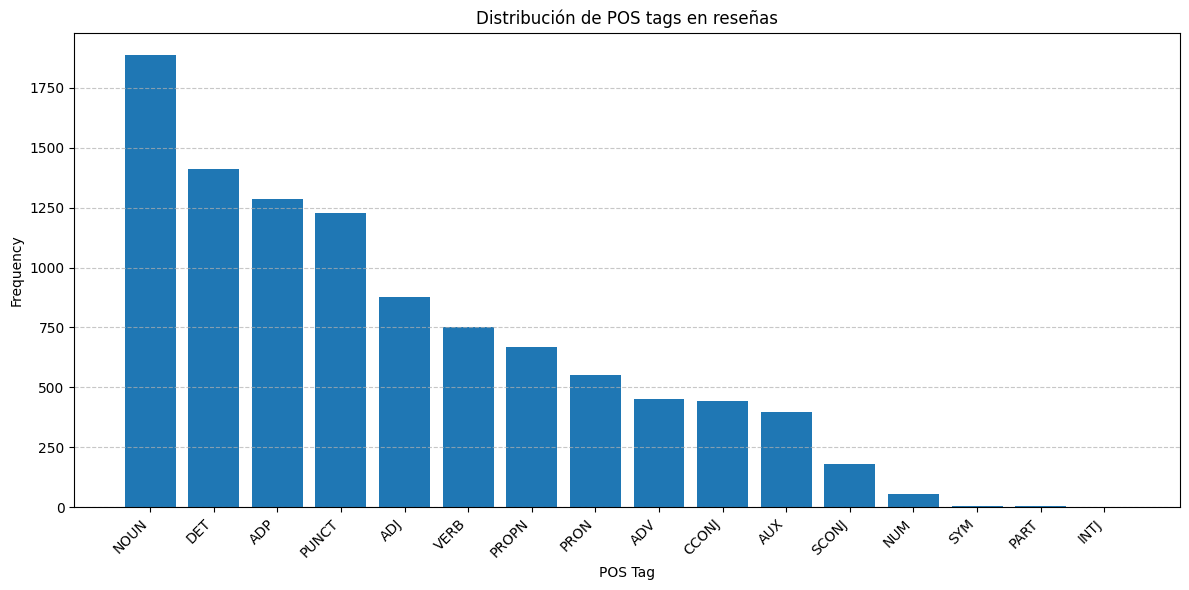

In [35]:
plt.figure(figsize=(12, 6))
plt.bar(tags, counts)
plt.xticks(rotation=45, ha='right')
plt.xlabel("POS Tag")
plt.ylabel("Frequency")
plt.title("Distribución de POS tags en reseñas")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [36]:
ent_counter = Counter()

for doc in nlp.pipe(datos["REVIEW_TEXT"][:100], batch_size=20):
    ent_counter.update([(ent.text, ent.label_) for ent in doc.ents])

In [37]:
ent_df = pd.DataFrame(ent_counter.items(), columns=["Entidad_Label", "Frecuencia"])
ent_df

,Entidad_Label,Frecuencia
0,"(Las medidas cocid, MISC)",1
1,"(Fidelina, LOC)",1
2,"(Los restaurantes, MISC)",2
3,"(Todo el personal, MISC)",2
4,"(Nuestro, PER)",4
...,...,...
573,"(Gato, MISC)",1
574,"(Doris, PER)",1
575,"(sericio, PER)",1
576,"(Destacar el gran trabajo, MISC)",1


In [38]:
ent_df[["Entidad", "Etiqueta"]] = pd.DataFrame(ent_df["Entidad_Label"].tolist(), index=ent_df.index)
ent_df

,Entidad_Label,Frecuencia,Entidad,Etiqueta
0,"(Las medidas cocid, MISC)",1,Las medidas cocid,MISC
1,"(Fidelina, LOC)",1,Fidelina,LOC
2,"(Los restaurantes, MISC)",2,Los restaurantes,MISC
3,"(Todo el personal, MISC)",2,Todo el personal,MISC
4,"(Nuestro, PER)",4,Nuestro,PER
...,...,...,...,...
573,"(Gato, MISC)",1,Gato,MISC
574,"(Doris, PER)",1,Doris,PER
575,"(sericio, PER)",1,sericio,PER
576,"(Destacar el gran trabajo, MISC)",1,Destacar el gran trabajo,MISC


In [39]:
ent_df = ent_df.drop(columns="Entidad_Label")
ent_df

,Frecuencia,Entidad,Etiqueta
0,1,Las medidas cocid,MISC
1,1,Fidelina,LOC
2,2,Los restaurantes,MISC
3,2,Todo el personal,MISC
4,4,Nuestro,PER
...,...,...,...
573,1,Gato,MISC
574,1,Doris,PER
575,1,sericio,PER
576,1,Destacar el gran trabajo,MISC


In [40]:
top_ents = ent_df.sort_values("Frecuencia", ascending=False).head(15)
top_ents

,Frecuencia,Entidad,Etiqueta
15,11,Secrets Cap Cana,ORG
35,7,Miguel,PER
78,7,Maria,PER
171,5,Leonardo,PER
233,4,Mención,MISC
253,4,Carlos,PER
37,4,Hotel,MISC
53,4,Concierge,PER
29,4,Volveremos,LOC
373,4,Diva,PER


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

In [42]:
datos['label'] = datos['RATING'].apply(lambda x: 0 if x <= 2 else 1)
X_train, X_test, y_train, y_test, idx_train, idx_test  = train_test_split(X, datos["label"],  datos.index, test_size=0.3, random_state=42, stratify=datos['label'])

clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.06      0.11       670
           1       0.94      1.00      0.97      9699

    accuracy                           0.94     10369
   macro avg       0.72      0.53      0.54     10369
weighted avg       0.91      0.94      0.91     10369



la Accuracy (Precisión) es una métrica de evaluación que mide la proporción de predicciones correctas que hizo un modelo sobre el total de predicciones. En términos más simples, te dice qué tan bien el modelo acertó en sus clasificaciones en general.

Se calcula como:

Accuracy = (Número de predicciones correctas) / (Número total de predicciones)

Por ejemplo, si tu modelo predijo correctamente 94 de cada 100 reseñas, su accuracy sería del 94%. Como vimos en el reporte anterior, tu modelo tiene una accuracy general del 0.94 (94%).

Sin embargo, es importante recordar que la accuracy puede ser engañosa en conjuntos de datos desequilibrados, como el tuyo. Si tienes muchas más reseñas positivas que negativas, un modelo puede obtener una alta accuracy simplemente prediciendo que casi todo es positivo, incluso si falla en identificar la minoría de reseñas negativas. Por eso, en tu caso, es crucial mirar otras métricas como la precision, recall y F1-score para cada clase.

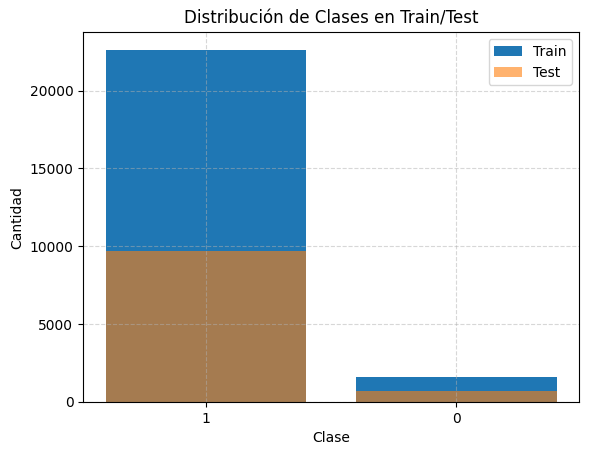

In [43]:
y_train_counts = y_train.value_counts()
y_test_counts = y_test.value_counts()

# Visualización
plt.bar(y_train_counts.index.astype(str), y_train_counts.values, label="Train")
plt.bar(y_test_counts.index.astype(str), y_test_counts.values, alpha=0.6, label="Test")
plt.title("Distribución de Clases en Train/Test")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

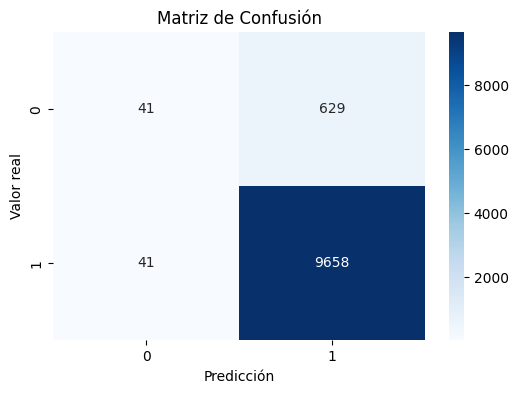

In [44]:
# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

# Visualizar matriz
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")
plt.show()

In [45]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.06      0.11       670
           1       0.94      1.00      0.97      9699

    accuracy                           0.94     10369
   macro avg       0.72      0.53      0.54     10369
weighted avg       0.91      0.94      0.91     10369



## 5️⃣ Interpretación del modelo

- Muestra las palabras más influyentes para cada clase (coeficientes del modelo)
- Interpreta qué tipo de lenguaje tiende a estar presente en reseñas positivas o negativas


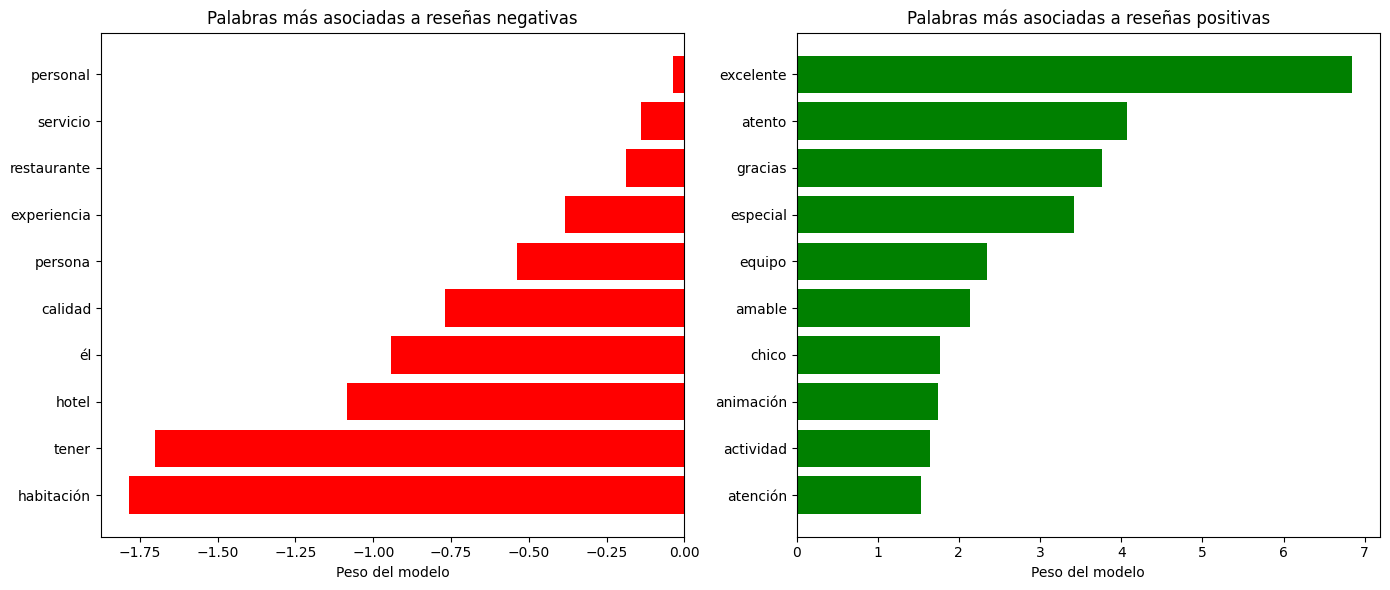

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Extraer coeficientes y términos
coefs = clf.coef_[0]
terms = vectorizer.get_feature_names_out()

# Obtener los términos más importantes para cada clase
top_n = 10
top_pos = np.argsort(coefs)[-top_n:]
top_neg = np.argsort(coefs)[:top_n]

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.barh(range(top_n), coefs[top_neg], align="center", color="red")
plt.yticks(range(top_n), [terms[i] for i in top_neg])
plt.title("Palabras más asociadas a reseñas negativas")
plt.xlabel("Peso del modelo")

plt.subplot(1, 2, 2)
plt.barh(range(top_n), coefs[top_pos], align="center", color="green")
plt.yticks(range(top_n), [terms[i] for i in top_pos])
plt.title("Palabras más asociadas a reseñas positivas")
plt.xlabel("Peso del modelo")

plt.tight_layout()
plt.show()

Palabras asociadas a reseñas positivas:

Analizando las palabras asociadas a las reseñas positivas (etiqueta '1'), observamos que los términos con mayor 'Peso del modelo' (model weight) son aquellos que contribuyen significativamente a que una reseña sea clasificada como positiva.

Basándome en los top_pos y sus coeficientes, las palabras más influyentes para las reseñas positivas incluyen:

excelente
amable
atento
especial
equipo
gracias
personal
animación
atención
vacación
Estas palabras sugieren que los huéspedes valoran mucho una experiencia excelente, un personal amable y atento, un servicio o trato especial, y disfrutan de la animación y el entretenimiento ofrecidos. La presencia de 'gracias' también indica una expresión directa de gratitud, lo cual se alinea con la retroalimentación positiva. Estos hallazgos concuerdan con lo que se esperaría encontrar en reseñas positivas de hoteles, destacando el buen servicio, las experiencias agradables y el aprecio general.





## 6️⃣ Prueba tu modelo

Selecciona una reseña del conjunto de test (o escribe una nueva) y predice su polaridad.


In [ ]:
# Prueba aquí tu modelo con una reseña de ejemplo...

In [48]:
# Define una nueva reseña para predecir
new_review_text = "El personal fue extremadamente amable y la comida deliciosa, pero la habitación era ruidosa y no pude dormir bien."

# 1. Limpiar la nueva reseña
cleaned_new_review = clean_text(new_review_text)
print(f"Reseña original: {new_review_text}")
print(f"Reseña limpia: {cleaned_new_review}")

# 2. Vectorizar la nueva reseña usando el mismo vectorizador TF-IDF
X_new = vectorizer.transform([cleaned_new_review])

# 3. Predecir la polaridad con el modelo entrenado
prediction = clf.predict(X_new)

# 4. Interpretar la predicción
if prediction[0] == 1:
    sentiment = "Positiva"
else:
    sentiment = "Negativa"

print(f"La polaridad predicha para la reseña es: {sentiment} (Clase: {prediction[0]})")

Reseña original: El personal fue extremadamente amable y la comida deliciosa, pero la habitación era ruidosa y no pude dormir bien.
Reseña limpia: personal extremadamente amable comida deliciós habitación ruidoso poder dormir
La polaridad predicha para la reseña es: Positiva (Clase: 1)


---

## ✅ Entregable

Guarda tu notebook con los resultados completos, asegurándote de incluir:

- Celdas comentadas y explicadas
- Visualizaciones generadas
- Interpretaciones escritas en celdas Markdown

Sube tu archivo `.ipynb` a la plataforma correspondiente.

¡Buena suerte!
